# Study 8 (Exp 1b) Mean Prevalence Judgments

Replicating figure that displays mean prevalence of test features with the 14 different conditions.

To visualize this data, there are two ways to collapse the mean prevalence of the test features. 
1. **number of generics** (0/4/8/12/16 generic statements); pooling across total number of utterances heard
2. **proportion of generics** (0/25/33/50/67/75/100% proportion of generic statmenets); pooling across total number of utterances heard

This uses information stored in `results/study8-vbmc-laplace-beta` and `results/study8-ablations`. The analyses
Rows: human data, the full GP + RSA model, and the **literal-listener lesion**
(specifics carry zero evidence: each group's utterances reduce to its generic-only set, groups
with identical generic sets merge — so all 0-generic conditions collapse into baseline;
refit to the study 8 data by `fit_study8_literal.py`, cached in `results/study8-ablations/`).

The models' diagnostic dissociation: the literal listener responds to the NUMBER of generics
but cannot care about the specifics it ignores, so PROPORTION does nothing beyond number;
the pragmatic model treats each specific as evidence against kind-linkedness, so proportion
matters — as it does in the human data (their regression: proportion survives number, not
vice versa). All model predictions are ratings-free; error bars are 95% CIs across
participants (for models: across participants' group-level predictions, i.e. config
variation).

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inference as inf
import studies68 as s68

inf.set_embed('2d')
FULL_DIR = os.path.join('results', 'study8-vbmc-laplace-beta')
ABL_DIR  = os.path.join('results', 'study8-ablations')

geom, responses_cond, groups_df = s68.load_study8()
J, test_feature_names = geom['J'], geom['test_feature_names']
meta = groups_df.set_index('group')

# participant-level table: one row per participant with their group + mean rating
rows = []
for g in responses_cond:
    R = np.array(responses_cond[g])                    # (N, 16)
    m = meta.loc[g]
    for i in range(R.shape[0]):
        rows.append({'group': g, 'condition': m['condition'],
                     'num_generics': int(m['num_generics']), 'total_utt': int(m['total_utt']),
                     'mean_rating': float(R[i].mean())})
ppl = pd.DataFrame(rows)
print(f"{len(ppl)} participants, {ppl.group.nunique()} groups")

load_study8: 507 of 524 rows kept after exclusions
load_study8: deduped repeated training tokens for row 483
load_study8: 403 groups (507 participants)
507 participants, 403 groups


## Forward passes

Full model: per-group ratings-free predictions from `results/study8-vbmc-laplace-beta/predictions.csv`.
Literal listener: computed here at its posterior median (per literal group, mapped back to the
original groups via `key_map`).

In [2]:
pred_full = pd.read_csv(os.path.join(FULL_DIR, 'predictions.csv'))   # group x feature long

def load_fit(path):
    z = np.load(path, allow_pickle=True)
    fit = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')}
    fit.update(json.loads(str(z['meta'])))
    return fit

fit_lit = load_fit(os.path.join(ABL_DIR, 'posterior-literal-matched.npz'))
print(f"literal fit: convergence={fit_lit['convergence_status']}  evals={fit_lit['func_count']}  "
      f"ELBO={fit_lit['elbo']:.1f}")
LSL, MUL, SIGL, BETAL = (float(np.median(fit_lit['ls_samples'])), float(np.median(fit_lit['mu0_samples'])),
                         float(np.median(fit_lit['sigma_samples'])), float(np.median(fit_lit['beta_samples'])))
print(f"literal posterior median: ls={LSL:.3f}, mu_0={MUL:.3f}, sigma={SIGL:.3f}, beta={BETAL:.3f}")

geom_lit, responses_lit, key_map = s68.literal_study8(responses_cond, groups_df, merge=False)
ll_lit, shapes_l, _ = inf.total_log_lik_free_shapes(geom_lit, responses_lit, LSL, MUL, SIGL,
                                                    beta_speaker=BETAL, return_shapes=True)
mean_kl_l  = shapes_l[:, 0] / (shapes_l[:, 0] + shapes_l[:, 1])
mean_nkl_l = shapes_l[:, 2] / (shapes_l[:, 2] + shapes_l[:, 3])
pz1_lit = inf.prior_pz1_modes(geom_lit, LSL, MUL, SIGL, beta_speaker=BETAL)
pred_lit_bykey = {k: np.asarray(pz1_lit[k]) * mean_kl_l + (1 - np.asarray(pz1_lit[k])) * mean_nkl_l
                  for k in responses_lit}

# long-form literal predictions per ORIGINAL group
lit_rows = []
for g in responses_cond:
    p = pred_lit_bykey[key_map[g]]
    m = meta.loc[g]
    for j, f in enumerate(test_feature_names):
        lit_rows.append({'group': g, 'condition': m['condition'],
                         'num_generics': int(m['num_generics']), 'total_utt': int(m['total_utt']),
                         'n_participants': int(m['n_participants']), 'feature': f,
                         'pred_prior': float(p[j])})
pred_litdf = pd.DataFrame(lit_rows)

# comparable model comparison: CONDITIONAL ratings likelihood log p(ratings | utterances)
# at each model's posterior median. Raw summed log Z is NOT comparable here because the
# two models condition on different utterance sets (the literal lesion stops paying the
# log p(u) terms of the specifics it drops).
th = np.load(os.path.join(FULL_DIR, 'fitted-link-shapes.npz'), allow_pickle=True)['theta']
cll_full = inf.conditional_ratings_log_lik(geom, responses_cond, *[float(v) for v in th[:3]],
                                           beta_speaker=float(th[3]))
cll_lit = inf.conditional_ratings_log_lik(geom_lit, responses_lit, LSL, MUL, SIGL,
                                          beta_speaker=BETAL)
print(f"log p(ratings | utterances) at posterior median:  full={cll_full:.1f}   "
      f"literal={cll_lit:.1f}   (full - literal = {cll_full - cll_lit:+.1f})")

literal fit: convergence=no  evals=400  ELBO=1670.8
literal posterior median: ls=2.041, mu_0=0.430, sigma=3.835, beta=808.432
literal_study8(merge=False): 403 literal groups (from 403)


log p(ratings | utterances) at posterior median:  full=2098.2   literal=2016.8   (full - literal = +81.5)


## r² with the human data

Per feature = participant-weighted condition × feature cells (240); per condition = the 15
condition means. Computed for both models against the same human aggregates.

In [3]:
def wavg(d, col): return float(np.average(d[col], weights=d['n_participants']))

emp_cells = (pred_full.groupby(['condition', 'feature'])
             .apply(lambda d: wavg(d, 'empirical_mean'), include_groups=False))
r2 = {}
for name, df in [('full (pragmatic)', pred_full), ('literal listener', pred_litdf)]:
    cells = (df.groupby(['condition', 'feature'])
             .apply(lambda d: wavg(d, 'pred_prior'), include_groups=False))
    r2_feat = np.corrcoef(cells.values, emp_cells.loc[cells.index].values)[0, 1] ** 2
    emp_c = emp_cells.groupby('condition').mean()
    mod_c = cells.groupby('condition').mean()
    r2_cond = np.corrcoef(mod_c.values, emp_c.loc[mod_c.index].values)[0, 1] ** 2
    r2[name] = dict(feat=r2_feat, cond=r2_cond)
    print(f"{name:<18} r2 per feature = {r2_feat:.2f}   r2 per condition = {r2_cond:.2f}")

full (pragmatic)   r2 per feature = 0.81   r2 per condition = 0.79
literal listener   r2 per feature = 0.78   r2 per condition = 0.60


## Collapsed bar figures (Exp 1b format)

Rows: human / full (pragmatic) / literal listener. Columns: collapsed by number of generics,
collapsed by proportion of generics. Dashed line = baseline (that row's own baseline value).
For the models each participant carries their own group's ratings-free predicted mean, so the
error bars reflect variation across training configurations.

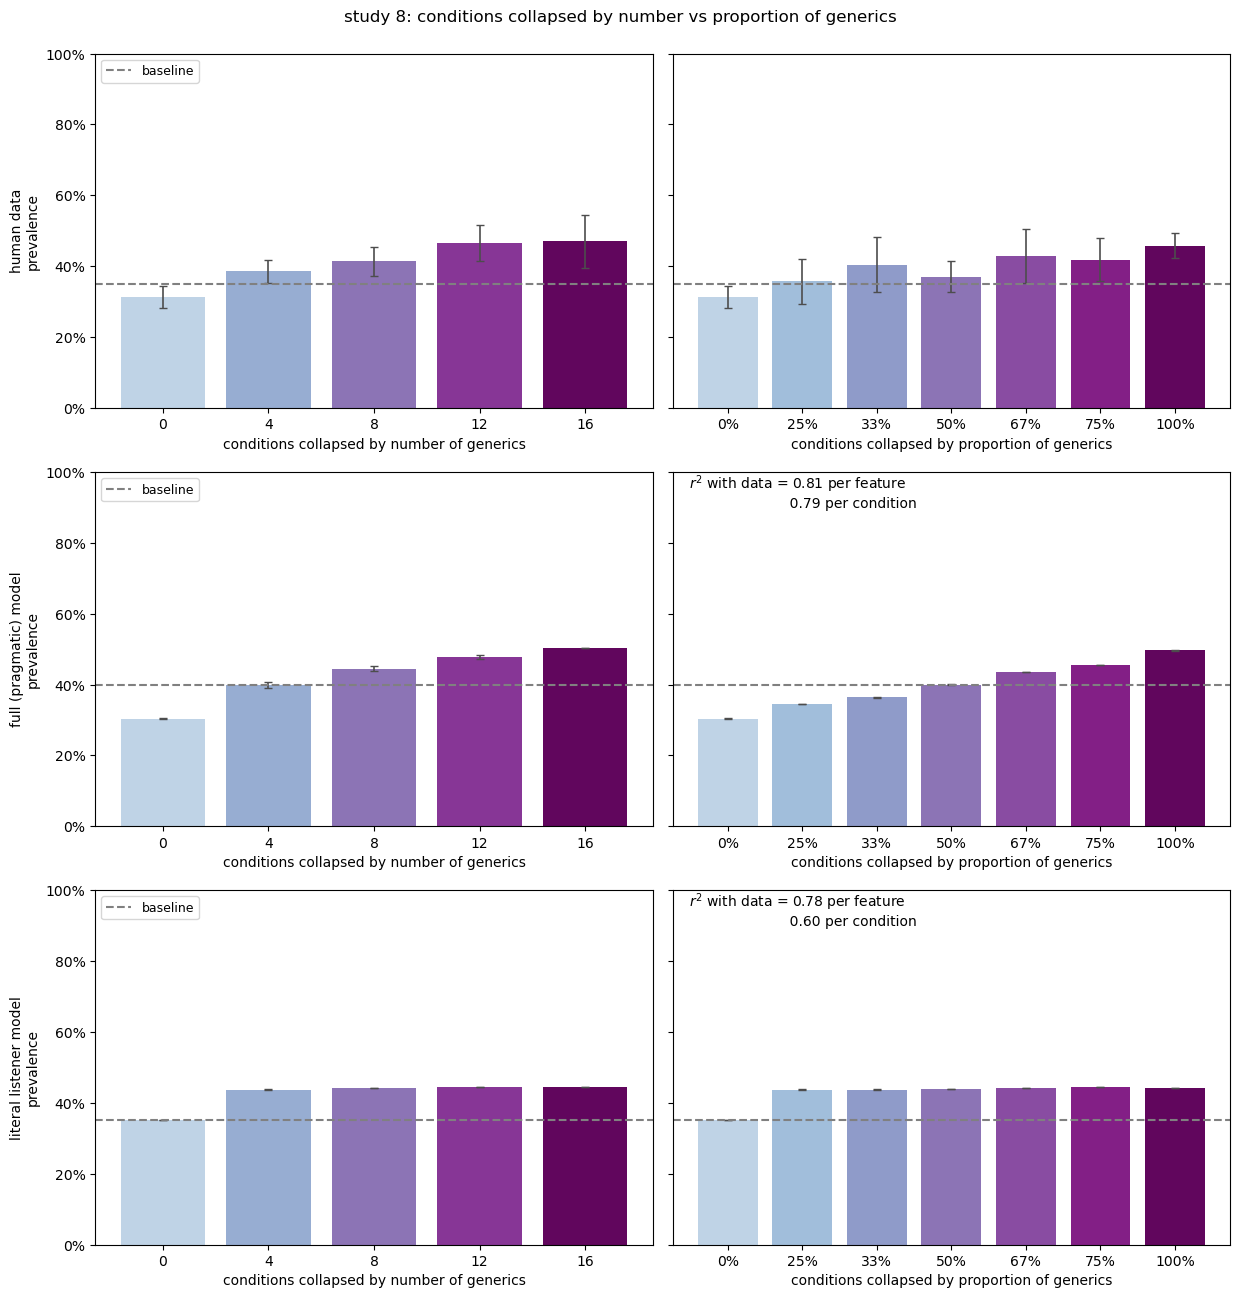

In [4]:
# per-participant predicted means for each model (participants inherit their group's value)
gp_full = pred_full.groupby('group')['pred_prior'].mean()
gp_lit  = pred_litdf.groupby('group')['pred_prior'].mean()
ppl['pred_full'] = ppl['group'].map(gp_full)
ppl['pred_lit']  = ppl['group'].map(gp_lit)

utt = ppl[ppl.condition != 'baseline'].copy()
utt['prop'] = utt.num_generics / utt.total_utt
PROP_ORDER  = [0.0, 0.25, 1/3, 0.5, 2/3, 0.75, 1.0]
PROP_LABELS = ['0%', '25%', '33%', '50%', '67%', '75%', '100%']
NG_ORDER = [0, 4, 8, 12, 16]

def collapse(col, by):
    order = NG_ORDER if by == 'ng' else PROP_ORDER
    key = utt.num_generics if by == 'ng' else utt.prop
    means, cis = [], []
    for v in order:
        vals = utt.loc[np.isclose(key, v), col]
        means.append(vals.mean()); cis.append(1.96 * vals.std(ddof=1) / np.sqrt(len(vals)))
    return np.array(means), np.array(cis)

ROWS = [('human data', 'mean_rating', None),
        ('full (pragmatic) model', 'pred_full', 'full (pragmatic)'),
        ('literal listener model', 'pred_lit', 'literal listener')]
base = ppl[ppl.condition == 'baseline']

fig, axes = plt.subplots(3, 2, figsize=(12.5, 13), sharey=True)
for (rname, col, r2key), (axL, axR) in zip(ROWS, axes):
    for ax, by, order, labels, xlab in [
            (axL, 'ng', NG_ORDER, [str(v) for v in NG_ORDER], 'conditions collapsed by number of generics'),
            (axR, 'prop', PROP_ORDER, PROP_LABELS, 'conditions collapsed by proportion of generics')]:
        m, ci = collapse(col, by)
        colors = plt.cm.BuPu(np.linspace(0.25, 0.95, len(order)))
        ax.bar(range(len(order)), m, yerr=ci, color=colors, capsize=3,
               error_kw=dict(lw=1.2, ecolor='0.3'))
        ax.axhline(base[col].mean(), ls='--', color='gray', label='baseline')
        ax.set_xticks(range(len(order))); ax.set_xticklabels(labels)
        ax.set_xlabel(xlab); ax.set_ylim(0, 1)
        ax.set_yticks(np.linspace(0, 1, 6))
        ax.set_yticklabels([f'{t:.0%}' for t in np.linspace(0, 1, 6)])
    axL.set_ylabel(f"{rname}\nprevalence")
    axL.legend(loc='upper left', fontsize=9)
    if r2key:
        axR.text(0.03, 0.9, f"$r^2$ with data = {r2[r2key]['feat']:.2f} per feature\n"
                            f"                       {r2[r2key]['cond']:.2f} per condition",
                 transform=axR.transAxes, fontsize=10)
fig.suptitle('study 8: conditions collapsed by number vs proportion of generics', y=0.995)
plt.tight_layout(); plt.show()

## Export for the R pipeline

Participant-weighted condition × feature model means in the `df_*_feature.csv` schema
(feature names as in the study 8 R pipeline: `cave`, `lion`, ... — the `_1`-stripped
Qualtrics columns), written to `model/scratch/study 8/`.

In [5]:
rname_of_feature = {v: k[:-2] for k, v in s68.STUDY8_COL_TO_FEATURE.items()}   # strip '_1'
scratch_dir = os.path.join('..', 'scratch', 'study 8')
os.makedirs(scratch_dir, exist_ok=True)
for df, fname in [(pred_full, 'df_gp_feature.csv'), (pred_litdf, 'df_gp_lit_feature.csv')]:
    cells = (df.groupby(['condition', 'feature'])
             .apply(lambda d: wavg(d, 'pred_prior'), include_groups=False)
             .rename('prevalence').reset_index())
    cells['feature'] = cells['feature'].map(rname_of_feature)
    cells.to_csv(os.path.join(ABL_DIR, fname), index=False)
    cells.to_csv(os.path.join(scratch_dir, fname), index=False)
    print(f"saved {fname} to {ABL_DIR}/ and {scratch_dir}/")

saved df_gp_feature.csv to results/study8-ablations/ and ../scratch/study 8/
saved df_gp_lit_feature.csv to results/study8-ablations/ and ../scratch/study 8/
